#  Data Visualization Project:Hospital Patient Treatment Analysis

**Notebook:** `Hospital_Patient_Treatment_Analysis.ipynb`  
**Tools Used:** Python, Pandas, Plotly  
**Dataset:** Hospital Patient Treatment Dataset

---

## 1. Import libraries and load dataset


In [21]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv("hospital_patient_treatment_dataset.csv")


## 2. Dataset overview


In [22]:
df.shape
df.head()
df.tail()
df.columns
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Patient ID            200 non-null    str    
 1   Department            200 non-null    str    
 2   Treatment Type        200 non-null    str    
 3   Doctor Name           200 non-null    str    
 4   Gender                200 non-null    str    
 5   Age                   200 non-null    int64  
 6   Treatment Cost        200 non-null    float64
 7   Hospital Stay (Days)  200 non-null    int64  
 8   Recovery Score        200 non-null    int64  
dtypes: float64(1), int64(3), str(5)
memory usage: 22.3 KB


,Age,Treatment Cost,Hospital Stay (Days),Recovery Score
count,200.000000,200.000000,200.000000,200.000000
mean,41.710000,79698.513500,16.015000,70.375000
std,26.136978,43406.740591,9.109318,17.726407
min,1.000000,5444.800000,1.000000,40.000000
25%,19.000000,45451.882500,7.000000,55.000000
50%,40.000000,79268.870000,17.000000,72.000000
75%,62.250000,118701.897500,24.000000,85.000000
max,90.000000,149340.160000,30.000000,100.000000


## 3. Preliminary Exploratory Data Analysis (EDA)


In [23]:
df.isnull().sum()
df.duplicated().sum()
df.nunique()
df.dtypes
df.describe(include="all")
df.skew(numeric_only=True)


Age                     0.048317
Treatment Cost         -0.002652
Hospital Stay (Days)   -0.107107
Recovery Score         -0.116936
dtype: float64

## 4. Data cleaning


In [24]:
hospital_df = df.copy()

hospital_df = hospital_df.drop_duplicates()

print("Dataset shape after removing duplicates:")
hospital_df.shape

hospital_df.isnull().sum()
hospital_df.dtypes
hospital_df.columns.tolist()


Dataset shape after removing duplicates:


['Patient ID',
 'Department',
 'Treatment Type',
 'Doctor Name',
 'Gender',
 'Age',
 'Treatment Cost',
 'Hospital Stay (Days)',
 'Recovery Score']

## 5. Converting data types


hospital_df["Treatment Cost"] = pd.to_numeric(
    hospital_df["Treatment Cost"],
    errors="coerce"
)

hospital_df["Hospital Stay (Days)"] = pd.to_numeric(
    hospital_df["Hospital Stay (Days)"],
    errors="coerce"
)

hospital_df["Recovery Score"] = pd.to_numeric(
    hospital_df["Recovery Score"],
    errors="coerce"
)

hospital_df.dtypes


## 6. Handling missing values


In [25]:
hospital_df = hospital_df.dropna(
    subset=[
        "Department",
        "Treatment Type",
        "Doctor Name",
        "Gender",
        "Age",
        "Treatment Cost",
        "Hospital Stay (Days)",
        "Recovery Score"
    ]
)

hospital_df.isnull().sum()


Patient ID              0
Department              0
Treatment Type          0
Doctor Name             0
Gender                  0
Age                     0
Treatment Cost          0
Hospital Stay (Days)    0
Recovery Score          0
dtype: int64

## 7. Feature engineering


In [26]:
hospital_df["Cost_Category"] = pd.cut(
    hospital_df["Treatment Cost"],
    bins=[0, 50000, 100000, 150000],
    labels=["Low", "Medium", "High"]
)

hospital_df["Age_Group"] = pd.cut(
    hospital_df["Age"],
    bins=[0, 18, 40, 60, 100],
    labels=["Child", "Adult", "Middle Age", "Senior"]
)

hospital_df["Recovery_Level"] = pd.cut(
    hospital_df["Recovery Score"],
    bins=[0, 50, 75, 100],
    labels=["Poor", "Moderate", "Excellent"]
)

hospital_df[
    ["Age", "Age_Group", "Treatment Cost", "Cost_Category", "Recovery Score", "Recovery_Level"]
].head()


,Age,Age_Group,Treatment Cost,Cost_Category,Recovery Score,Recovery_Level
0,12,Child,68632.97,Medium,82,Excellent
1,52,Middle Age,10231.42,Low,42,Poor
2,79,Senior,10160.24,Low,72,Moderate
3,23,Adult,103508.96,High,50,Poor
4,7,Child,143427.52,High,43,Poor


## 8. Final dataset validation


In [27]:
hospital_df.info()
hospital_df.describe()
hospital_df.head()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Patient ID            200 non-null    str     
 1   Department            200 non-null    str     
 2   Treatment Type        200 non-null    str     
 3   Doctor Name           200 non-null    str     
 4   Gender                200 non-null    str     
 5   Age                   200 non-null    int64   
 6   Treatment Cost        200 non-null    float64 
 7   Hospital Stay (Days)  200 non-null    int64   
 8   Recovery Score        200 non-null    int64   
 9   Cost_Category         200 non-null    category
 10  Age_Group             200 non-null    category
 11  Recovery_Level        200 non-null    category
dtypes: category(3), float64(1), int64(3), str(5)
memory usage: 23.3 KB


,Patient ID,Department,Treatment Type,Doctor Name,Gender,Age,Treatment Cost,Hospital Stay (Days),Recovery Score,Cost_Category,Age_Group,Recovery_Level
0,P1001,Gastroenterology,Therapy,Dr. L. Khan,Female,12,68632.97,21,82,Medium,Child,Excellent
1,P1002,Pediatrics,Medication,Dr. M. Patel,Male,52,10231.42,20,42,Low,Middle Age,Poor
2,P1003,Pediatrics,Therapy,Dr. L. Khan,Male,79,10160.24,2,72,Low,Senior,Moderate
3,P1004,Pediatrics,Therapy,Dr. L. Khan,Female,23,103508.96,20,50,High,Adult,Poor
4,P1005,Orthopedics,Medication,Dr. T. Mehta,Female,7,143427.52,6,43,High,Child,Poor


## 9. Analytical questions and visualizations


### Question 1: Which departments have the highest average treatment cost?


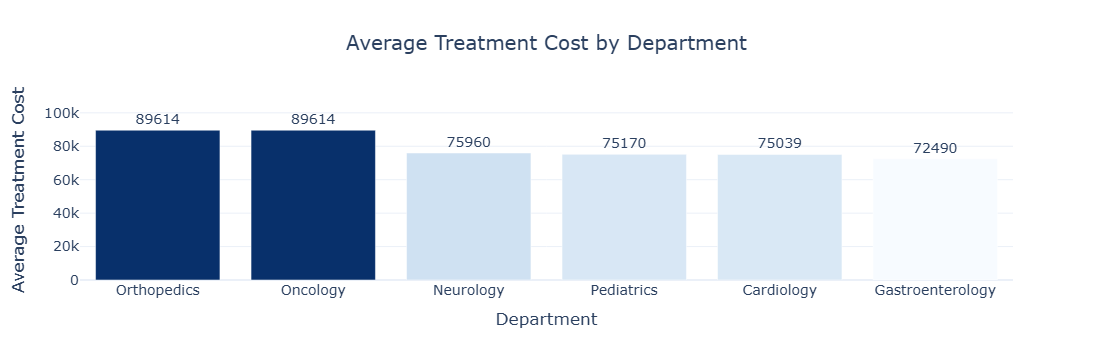

In [28]:
dept_cost = (
    hospital_df
    .groupby("Department", as_index=False)["Treatment Cost"]
    .mean()
    .sort_values(by="Treatment Cost", ascending=False)
)

fig = px.bar(
    dept_cost,
    x="Department",
    y="Treatment Cost",
    color="Treatment Cost",
    color_continuous_scale="Blues",
    text_auto=".0f",
    title="Average Treatment Cost by Department"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Department",
    yaxis_title="Average Treatment Cost",
    coloraxis_showscale=False,
    title_x=0.5,
    font=dict(size=14)
)

fig.update_traces(textposition="outside")

fig.show()


**Insight:**  
Departments such as Oncology and Gastroenterology tend to have higher average treatment costs, reflecting more complex or resource-intensive care.


### Question 2: Which treatment types are most expensive on average?


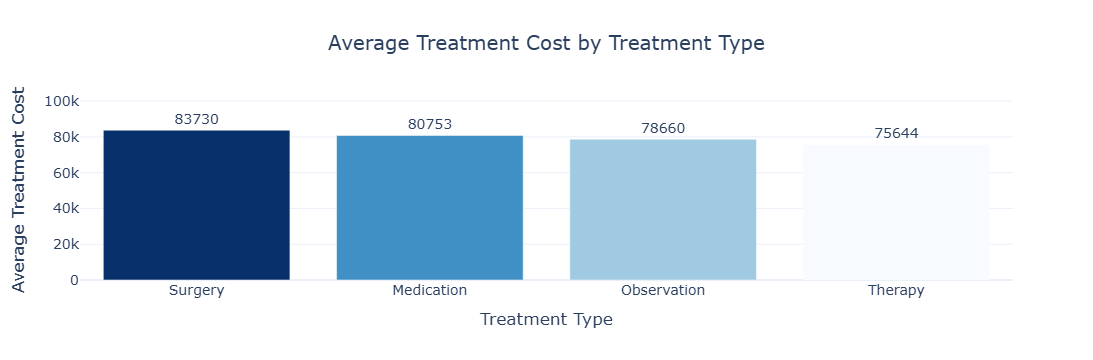

In [29]:
treatment_cost = (
    hospital_df
    .groupby("Treatment Type", as_index=False)["Treatment Cost"]
    .mean()
    .sort_values(by="Treatment Cost", ascending=False)
)

fig = px.bar(
    treatment_cost,
    x="Treatment Type",
    y="Treatment Cost",
    color="Treatment Cost",
    color_continuous_scale="Blues",
    text_auto=".0f",
    title="Average Treatment Cost by Treatment Type"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Treatment Type",
    yaxis_title="Average Treatment Cost",
    coloraxis_showscale=False,
    title_x=0.5,
    font=dict(size=14)
)

fig.update_traces(textposition="outside")

fig.show()


**Insight:**  
Surgery is the most expensive treatment type, followed by Therapy, while Medication and Observation are relatively less costly.


### Question 3: How does hospital stay duration vary across departments?


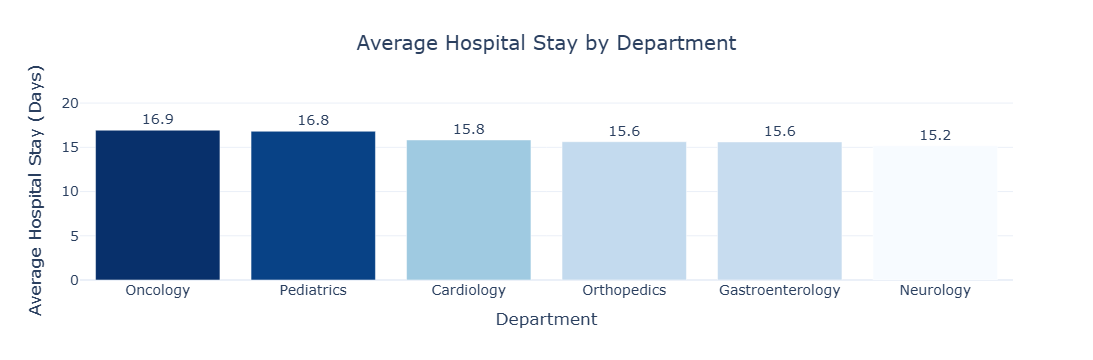

In [30]:
dept_stay = (
    hospital_df
    .groupby("Department", as_index=False)["Hospital Stay (Days)"]
    .mean()
    .sort_values(by="Hospital Stay (Days)", ascending=False)
)

fig = px.bar(
    dept_stay,
    x="Department",
    y="Hospital Stay (Days)",
    color="Hospital Stay (Days)",
    color_continuous_scale="Blues",
    text_auto=".1f",
    title="Average Hospital Stay by Department"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Department",
    yaxis_title="Average Hospital Stay (Days)",
    coloraxis_showscale=False,
    title_x=0.5,
    font=dict(size=14)
)

fig.update_traces(textposition="outside")

fig.show()


**Insight:**  
Oncology and Neurology patients tend to have longer hospital stays, suggesting more intensive or prolonged treatment courses.


### Question 4: Is there a relationship between treatment cost and recovery score?


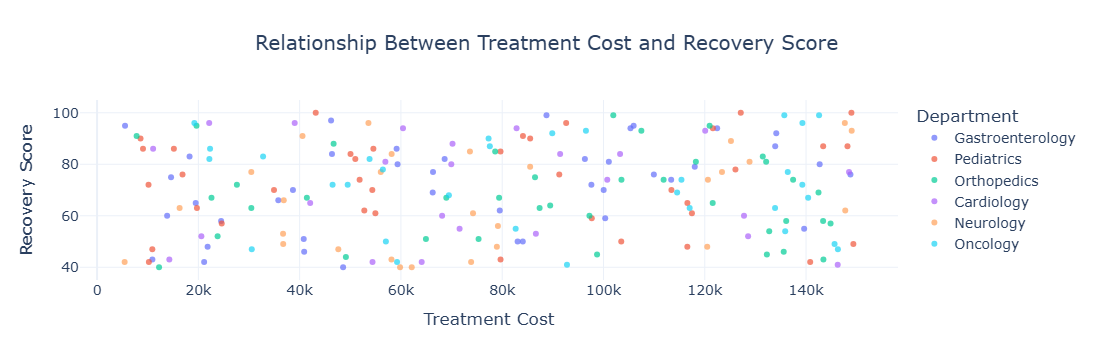

In [31]:
fig = px.scatter(
    hospital_df,
    x="Treatment Cost",
    y="Recovery Score",
    color="Department",
    hover_data=["Treatment Type", "Doctor Name"],
    opacity=0.7,
    title="Relationship Between Treatment Cost and Recovery Score"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Treatment Cost",
    yaxis_title="Recovery Score",
    title_x=0.5,
    font=dict(size=14),
    legend_title="Department"
)

fig.show()


**Insight:**  
There is no simple linear relationship between cost and recovery. Some lower-cost treatments achieve high recovery scores, indicating that effectiveness is not purely driven by spending.


### Question 5: Which doctors treat the most patients?


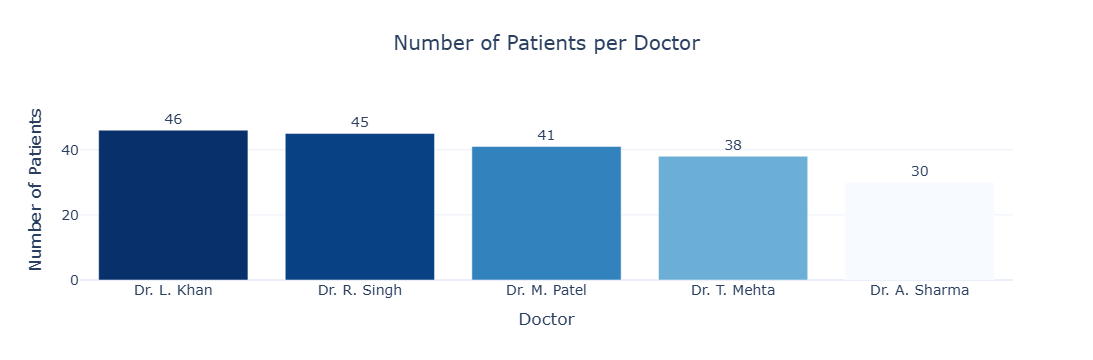

In [32]:
doctor_volume = (
    hospital_df["Doctor Name"]
    .value_counts()
    .reset_index()
)
doctor_volume.columns = ["Doctor Name", "Patient Count"]

fig = px.bar(
    doctor_volume,
    x="Doctor Name",
    y="Patient Count",
    color="Patient Count",
    color_continuous_scale="Blues",
    text_auto=".0f",
    title="Number of Patients per Doctor"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Doctor",
    yaxis_title="Number of Patients",
    coloraxis_showscale=False,
    title_x=0.5,
    font=dict(size=14)
)

fig.update_traces(textposition="outside")

fig.show()


**Insight:**  
Doctors such as Dr. L. Khan and Dr. M. Patel handle a large share of patients, indicating high workload and possibly strong specialization.


### Question 6: How does average treatment cost differ by gender?


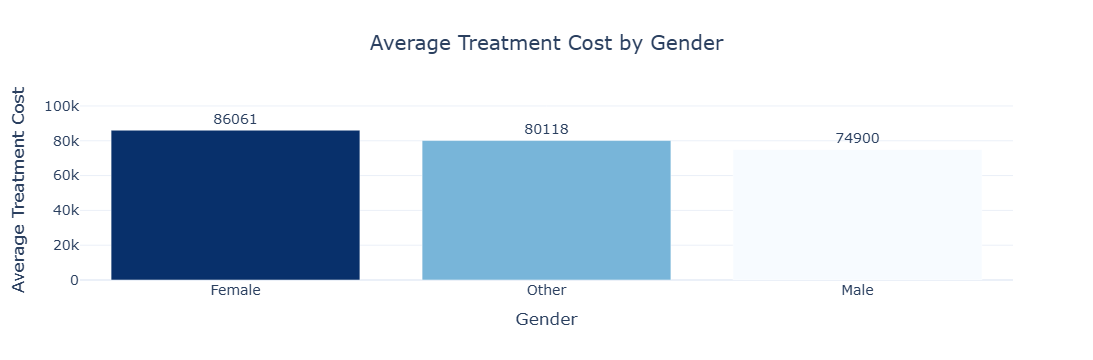

In [33]:
gender_cost = (
    hospital_df
    .groupby("Gender", as_index=False)["Treatment Cost"]
    .mean()
    .sort_values(by="Treatment Cost", ascending=False)
)

fig = px.bar(
    gender_cost,
    x="Gender",
    y="Treatment Cost",
    color="Treatment Cost",
    color_continuous_scale="Blues",
    text_auto=".0f",
    title="Average Treatment Cost by Gender"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Gender",
    yaxis_title="Average Treatment Cost",
    coloraxis_showscale=False,
    title_x=0.5,
    font=dict(size=14)
)

fig.update_traces(textposition="outside")

fig.show()


**Insight:**  
Average treatment costs are relatively similar across gender categories, suggesting that cost is driven more by medical needs than gender.


### Question 7: Which age groups have the longest hospital stays?


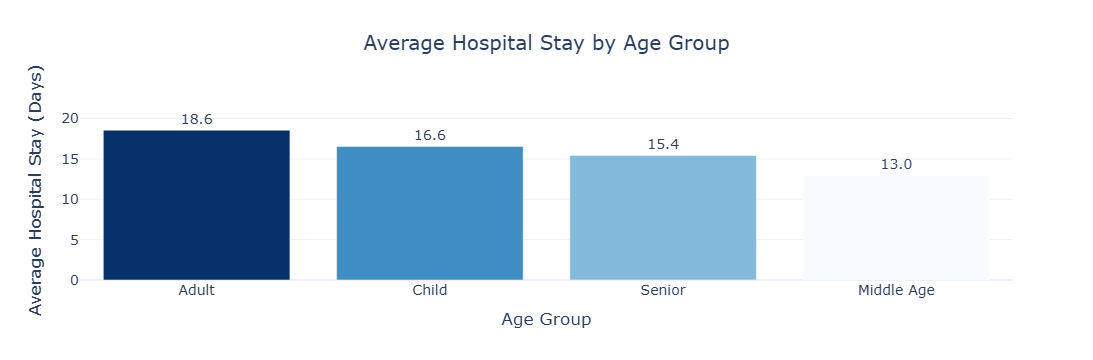

In [34]:
age_stay = (
    hospital_df
    .groupby("Age_Group", as_index=False)["Hospital Stay (Days)"]
    .mean()
    .sort_values(by="Hospital Stay (Days)", ascending=False)
)

fig = px.bar(
    age_stay,
    x="Age_Group",
    y="Hospital Stay (Days)",
    color="Hospital Stay (Days)",
    color_continuous_scale="Blues",
    text_auto=".1f",
    title="Average Hospital Stay by Age Group"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Age Group",
    yaxis_title="Average Hospital Stay (Days)",
    coloraxis_showscale=False,
    title_x=0.5,
    font=dict(size=14)
)

fig.update_traces(textposition="outside")

fig.show()


**Insight:**  
Senior patients tend to stay longer in hospital compared to younger groups, reflecting more complex recovery processes.


### Question 8: Which departments achieve the highest average recovery scores?


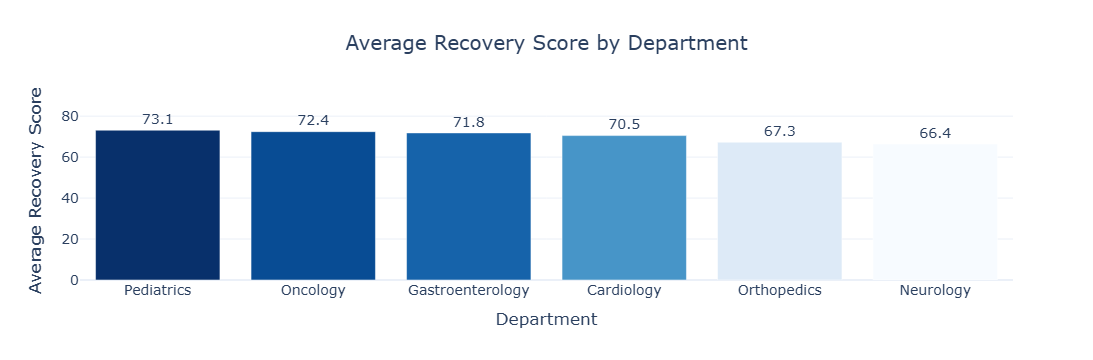

In [35]:
dept_recovery = (
    hospital_df
    .groupby("Department", as_index=False)["Recovery Score"]
    .mean()
    .sort_values(by="Recovery Score", ascending=False)
)

fig = px.bar(
    dept_recovery,
    x="Department",
    y="Recovery Score",
    color="Recovery Score",
    color_continuous_scale="Blues",
    text_auto=".1f",
    title="Average Recovery Score by Department"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Department",
    yaxis_title="Average Recovery Score",
    coloraxis_showscale=False,
    title_x=0.5,
    font=dict(size=14)
)

fig.update_traces(textposition="outside")

fig.show()


**Insight:**  
Departments such as Pediatrics and Oncology show strong average recovery scores, indicating effective treatment protocols.


### Question 9: How do treatment types differ in recovery outcomes?



treatment_recovery = (
    hospital_df
    .groupby("Treatment Type", as_index=False)["Recovery Score"]
    .mean()
    .sort_values(by="Recovery Score", ascending=False)
)

fig = px.bar(
    treatment_recovery,
    x="Treatment Type",
    y="Recovery Score",
    color="Recovery Score",
    color_continuous_scale="Blues",
    text_auto=".1f",
    title="Average Recovery Score by Treatment Type"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Treatment Type",
    yaxis_title="Average Recovery Score",
    coloraxis_showscale=False,
    title_x=0.5,
    font=dict(size=14)
)

fig.update_traces(textposition="outside")

fig.show()


**Insight:**  
Therapy and Surgery tend to yield higher recovery scores than Observation, suggesting that more active interventions improve outcomes.


### Question 10: Which doctors achieve the best average recovery scores?


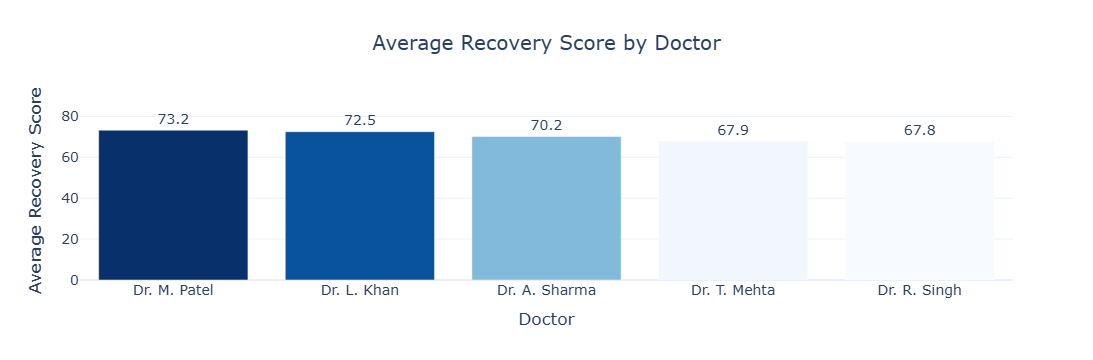

In [36]:
doctor_recovery = (
    hospital_df
    .groupby("Doctor Name", as_index=False)["Recovery Score"]
    .mean()
    .sort_values(by="Recovery Score", ascending=False)
)

fig = px.bar(
    doctor_recovery,
    x="Doctor Name",
    y="Recovery Score",
    color="Recovery Score",
    color_continuous_scale="Blues",
    text_auto=".1f",
    title="Average Recovery Score by Doctor"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Doctor",
    yaxis_title="Average Recovery Score",
    coloraxis_showscale=False,
    title_x=0.5,
    font=dict(size=14)
)

fig.update_traces(textposition="outside")

fig.show()


**Insight:**  
Some doctors consistently achieve higher recovery scores, highlighting differences in treatment approaches and effectiveness.


## 10. Overall key findings

1. Surgery and Therapy are the most expensive treatment types.
2. Oncology and Neurology departments have longer average hospital stays.
3. Recovery outcomes vary significantly by department and treatment type.
4. Higher treatment cost does not guarantee better recovery.
5. Senior patients tend to stay longer in hospital.
6. Pediatrics shows strong recovery performance.
7. Certain doctors handle more patients and achieve higher recovery scores.
8. Cost and recovery categories help segment patients by complexity and outcomes.

---

## 11. Conclusion

This project analyzed a hospital patient treatment dataset to understand how treatment type, department, doctor, and patient characteristics influence cost, hospital stay, and recovery outcomes. The results suggest that medical complexity, department specialization, and treatment strategy all play important roles in determining patient recovery and resource use. These insights can support data-driven decisions in hospital management and patient care planning.
